# Lesson 3 — What is a Surrogate?

From Lesson 2 we know that gradient descent fails on expensive, noisy, black-box functions.

The solution: build a **surrogate** — a cheap model that approximates the expensive function using only a small number of evaluations. Then optimise the cheap model instead.

In this lesson you will:
1. Understand the surrogate concept with a visual example
2. See how more training points improve the surrogate
3. Understand overfitting vs. underfitting in surrogate models
4. Run the full **surrogate loop** — the core algorithm used in every lesson from here on
5. See where polynomial surrogates fail — motivation for GP and neural networks

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

X_PLOT = np.linspace(0, 1, 300)
print('Imports OK')

Imports OK


---
## The Expensive Function

We will use the **Forrester function** — a standard 1D benchmark in surrogate optimisation.

Pretend each call to `forrester(x)` costs 1 hour of compute. We can only afford a few calls.

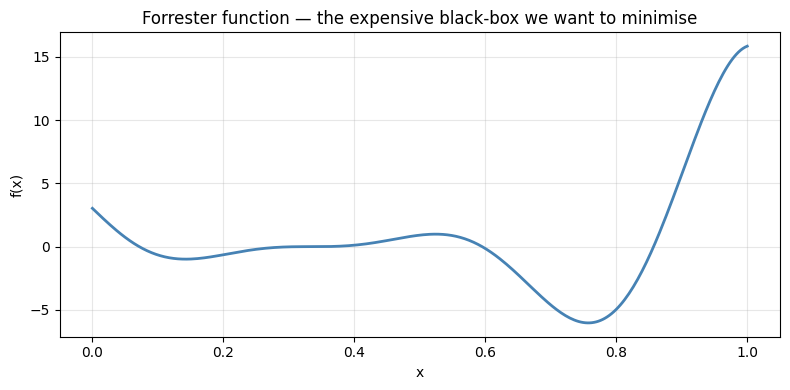

True minimum ≈ f(0.756) = -6.020


In [2]:
def forrester(x):
    return (6*x - 2)**2 * np.sin(12*x - 4)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(X_PLOT, forrester(X_PLOT), color='steelblue', linewidth=2)
ax.set_title('Forrester function — the expensive black-box we want to minimise')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

true_min_idx = np.argmin(forrester(X_PLOT))
print(f'True minimum ≈ f({X_PLOT[true_min_idx]:.3f}) = {forrester(X_PLOT)[true_min_idx]:.3f}')

---
## Part 1 — The Surrogate Concept

The idea:
1. Evaluate the expensive function at a few points → get `(x, f(x))` pairs
2. Fit a cheap model (surrogate) to those pairs
3. Use the surrogate to predict `f(x)` everywhere — for free
4. Use the surrogate to decide where to evaluate next

Our first surrogate: **polynomial regression** via `np.polyfit`.

In [3]:
# 5 expensive evaluations
X_train = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
y_train = forrester(X_train)

print('Training data:')
for x, y in zip(X_train, y_train):
    print(f'  x={x:.1f}  →  f(x)={y:.3f}')

Training data:
  x=0.1  →  f(x)=-0.657
  x=0.3  →  f(x)=-0.016
  x=0.5  →  f(x)=0.909
  x=0.7  →  f(x)=-4.606
  x=0.9  →  f(x)=5.712


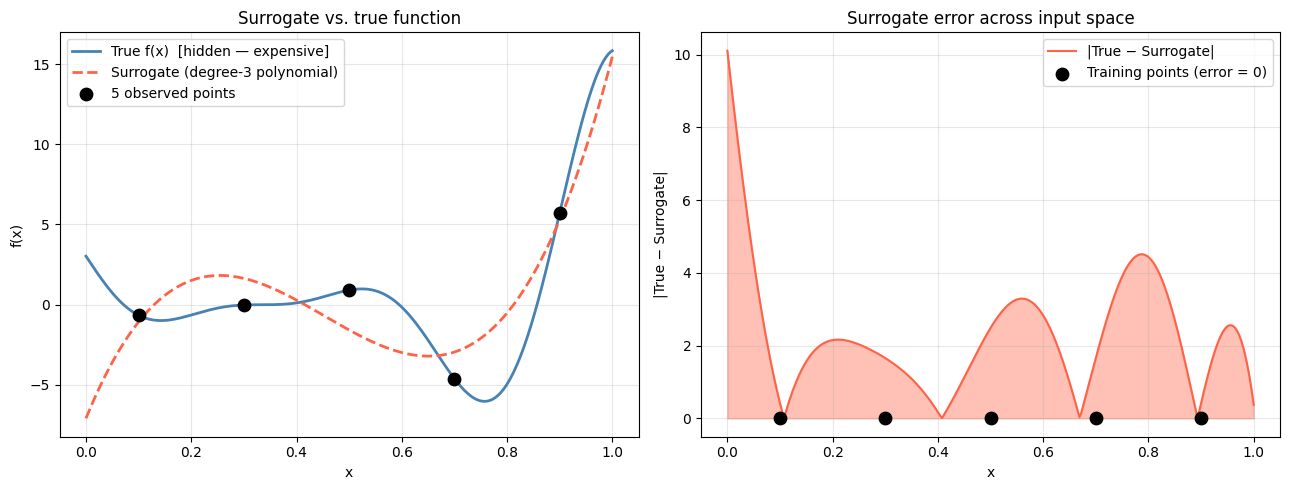

In [7]:
# Fit a degree-3 polynomial to the 5 observations
coeffs = np.polyfit(X_train, y_train, deg=3)
surrogate = np.poly1d(coeffs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(X_PLOT, forrester(X_PLOT), color='steelblue', linewidth=2,
             label='True f(x)  [hidden — expensive]')
axes[0].plot(X_PLOT, surrogate(X_PLOT), color='tomato', linewidth=2,
             linestyle='--', label='Surrogate (degree-3 polynomial)')
axes[0].scatter(X_train, y_train, color='black', s=80, zorder=5, label='5 observed points')
axes[0].set_title('Surrogate vs. true function')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

error = np.abs(forrester(X_PLOT) - surrogate(X_PLOT))
axes[1].fill_between(X_PLOT, 0, error, color='tomato', alpha=0.4)
axes[1].plot(X_PLOT, error, color='tomato', linewidth=1.5, label='|True − Surrogate|')
axes[1].scatter(X_train, np.zeros_like(X_train), color='black', s=80,
                zorder=5, label='Training points (error = 0)')
axes[1].set_title('Surrogate error across input space')
axes[1].set_xlabel('x')
axes[1].set_ylabel('|True − Surrogate|')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The surrogate is exact at the training points (error = 0) but wrong everywhere else.
This gap is called **interpolation error** or **surrogate uncertainty**.

A key weakness of polynomial regression: it gives no indication of *where* it is uncertain.
Later, GP and neural networks with MC Dropout will fix this.

**Try it:** Change `deg=3` to `deg=1`. How does the surrogate change?

---
## Part 2 — Effect of Number of Training Points

More evaluations = better surrogate. But each evaluation is expensive, so we want as few as possible.

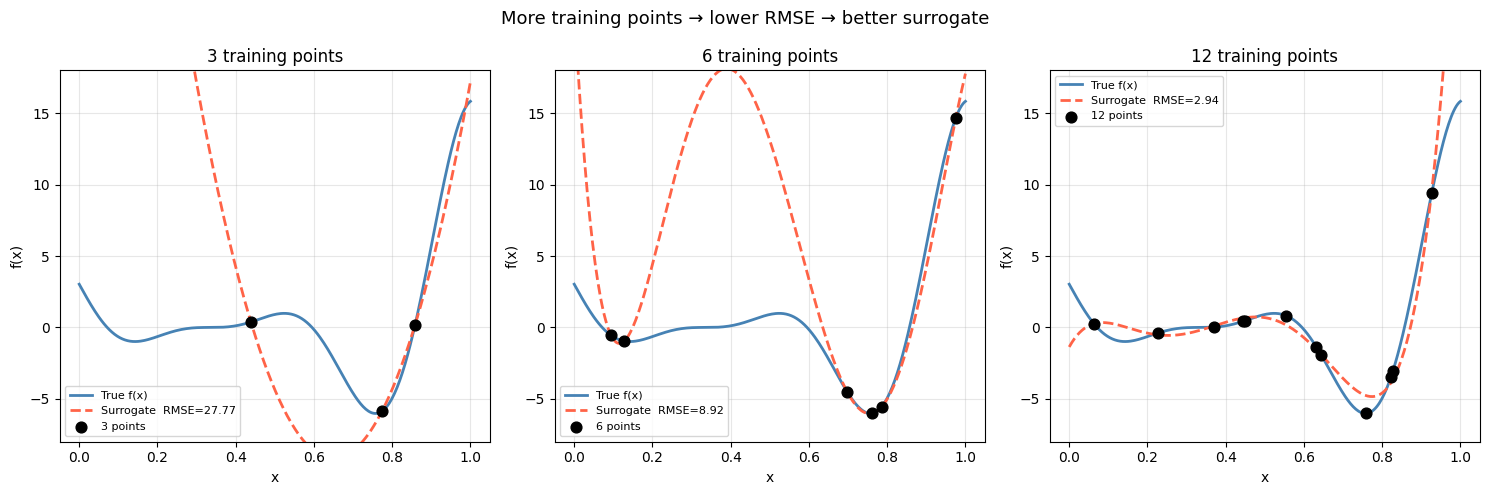

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, [3, 6, 12]):
    X_n = np.sort(rng.uniform(0, 1, n))
    y_n = forrester(X_n)
    deg = min(n - 1, 5)
    poly_n = np.poly1d(np.polyfit(X_n, y_n, deg))

    rmse = np.sqrt(np.mean((forrester(X_PLOT) - poly_n(X_PLOT))**2))

    ax.plot(X_PLOT, forrester(X_PLOT), color='steelblue', linewidth=2, label='True f(x)')
    ax.plot(X_PLOT, poly_n(X_PLOT), color='tomato', linewidth=2,
            linestyle='--', label=f'Surrogate  RMSE={rmse:.2f}')
    ax.scatter(X_n, y_n, color='black', s=60, zorder=5, label=f'{n} points')
    ax.set_title(f'{n} training points')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-8, 18)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('More training points → lower RMSE → better surrogate', fontsize=13)
plt.tight_layout()
plt.show()

RMSE (Root Mean Squared Error) measures how far the surrogate is from the true function on average. Lower is better.

**Try it:** Change the number of points to `[5, 10, 20]`. At what point does the surrogate look almost perfect?

---
## Part 3 — Overfitting vs. Underfitting

The **polynomial degree** controls model complexity:
- **Too low (underfitting)** — the model is too simple to capture the shape
- **Too high (overfitting)** — the model memorises the training points but oscillates wildly between them

This is a fundamental problem in all surrogate modelling, not just polynomials.

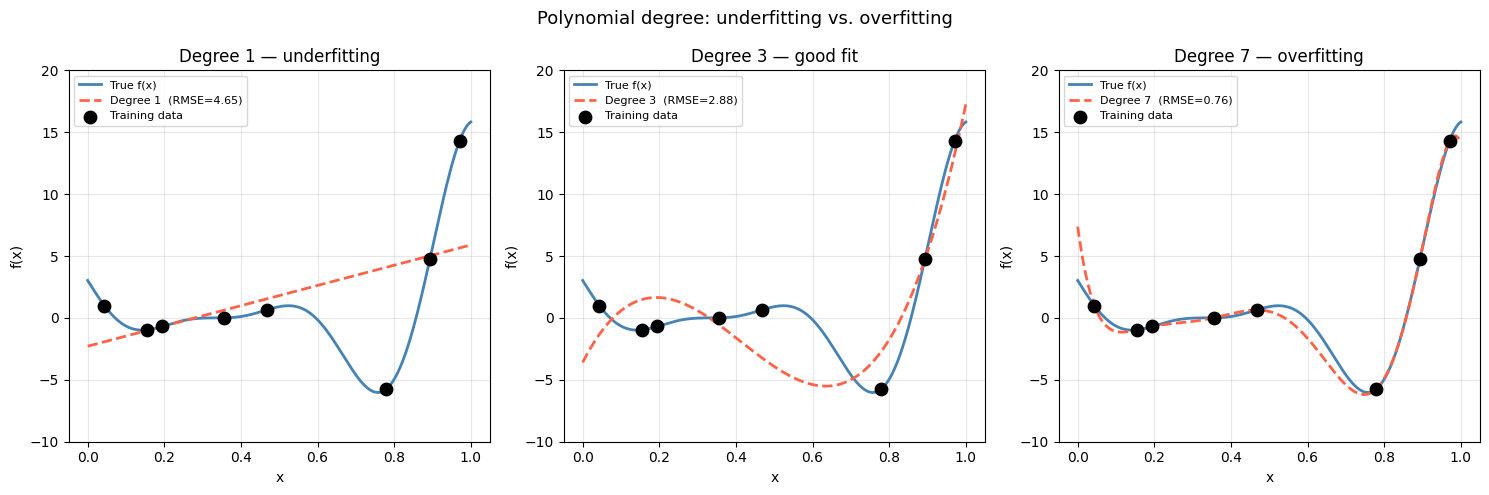

In [9]:
X_fixed = np.sort(rng.uniform(0, 1, 8))
y_fixed  = forrester(X_fixed)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    (1, 'Degree 1 — underfitting'),
    (3, 'Degree 3 — good fit'),
    (7, 'Degree 7 — overfitting'),
]

for ax, (deg, title) in zip(axes, configs):
    poly_d = np.poly1d(np.polyfit(X_fixed, y_fixed, deg))
    y_hat  = poly_d(X_PLOT)
    rmse   = np.sqrt(np.mean((forrester(X_PLOT) - y_hat)**2))

    ax.plot(X_PLOT, forrester(X_PLOT), color='steelblue', linewidth=2, label='True f(x)')
    ax.plot(X_PLOT, np.clip(y_hat, -20, 30), color='tomato', linewidth=2,
            linestyle='--', label=f'Degree {deg}  (RMSE={rmse:.2f})')
    ax.scatter(X_fixed, y_fixed, color='black', s=80, zorder=5, label='Training data')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-10, 20)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial degree: underfitting vs. overfitting', fontsize=13)
plt.tight_layout()
plt.show()

Degree 7 passes through all 8 training points perfectly — but oscillates wildly between them. If we used it to pick the next evaluation point, we would evaluate somewhere completely wrong.

**Try it:** Change degree to `9`. What happens at the edges (x near 0 and 1)?

---
## Part 4 — The Surrogate Loop

This is the core algorithm used in all surrogate-assisted optimisation:

```
1. Start with a small set of observed points
2. Fit the surrogate to those points
3. Find the minimum of the surrogate (cheap!)
4. Evaluate the true function at that point (expensive — one call)
5. Add the new point to the dataset
6. Go back to step 2
```

In Lesson 8 we will make step 3 smarter using **acquisition functions**. For now, we just pick the surrogate minimum.

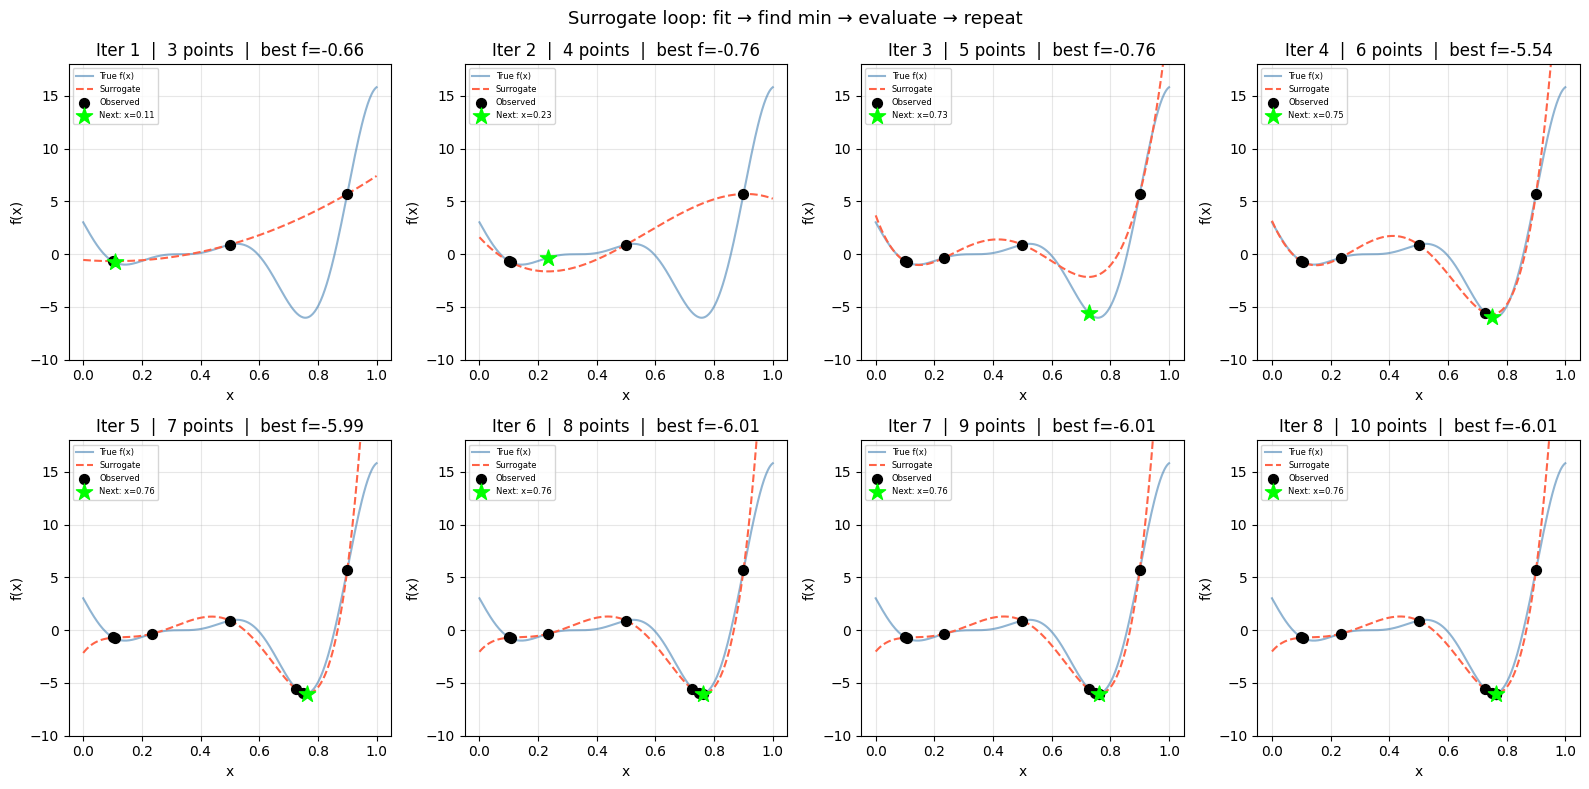

Best found: f(0.7625) = -6.0056
True minimum: f(0.757) ≈ -6.02


In [10]:
X_obs = np.array([0.1, 0.5, 0.9])
y_obs = forrester(X_obs)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    degree = min(len(X_obs) - 1, 5)
    poly_i = np.poly1d(np.polyfit(X_obs, y_obs, degree))

    # Pick next point: minimum of the surrogate
    y_surr  = poly_i(X_PLOT)
    x_next  = X_PLOT[np.argmin(y_surr)]
    y_next  = forrester(x_next)

    ax = axes[i]
    ax.plot(X_PLOT, forrester(X_PLOT), color='steelblue', linewidth=1.5,
            label='True f(x)', alpha=0.6)
    ax.plot(X_PLOT, np.clip(y_surr, -15, 20), color='tomato', linewidth=1.5,
            linestyle='--', label='Surrogate')
    ax.scatter(X_obs, y_obs, color='black', s=50, zorder=5, label='Observed')
    ax.scatter([x_next], [y_next], color='lime', s=150, zorder=6,
               marker='*', label=f'Next: x={x_next:.2f}')
    ax.set_title(f'Iter {i+1}  |  {len(X_obs)} points  |  best f={y_obs.min():.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-10, 18)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

    X_obs = np.append(X_obs, x_next)
    y_obs = np.append(y_obs, y_next)

plt.suptitle('Surrogate loop: fit → find min → evaluate → repeat', fontsize=13)
plt.tight_layout()
plt.show()

best_idx = np.argmin(y_obs)
print(f'Best found: f({X_obs[best_idx]:.4f}) = {y_obs[best_idx]:.4f}')
print(f'True minimum: f(0.757) ≈ -6.02')

Watch the green star (next point) move closer to the true minimum as the surrogate improves.

**Problem you will notice:** the loop keeps picking points near the same region. It is not exploring enough. This is the **exploration vs. exploitation** problem — fixed in Lesson 7 with acquisition functions.

**Try it:** Change the initial points from `[0.1, 0.5, 0.9]` to `[0.2, 0.25, 0.3]` (clustered). What happens?

---
## Part 5 — Where Polynomial Surrogates Fail

Polynomial regression has two fundamental problems:

1. **Multimodal functions** — many peaks and valleys that a polynomial cannot capture
2. **No uncertainty** — the polynomial gives a number but no indication of confidence

Both problems are fixed by Gaussian Processes (Lesson 6) and neural networks with MC Dropout (Lesson 10).

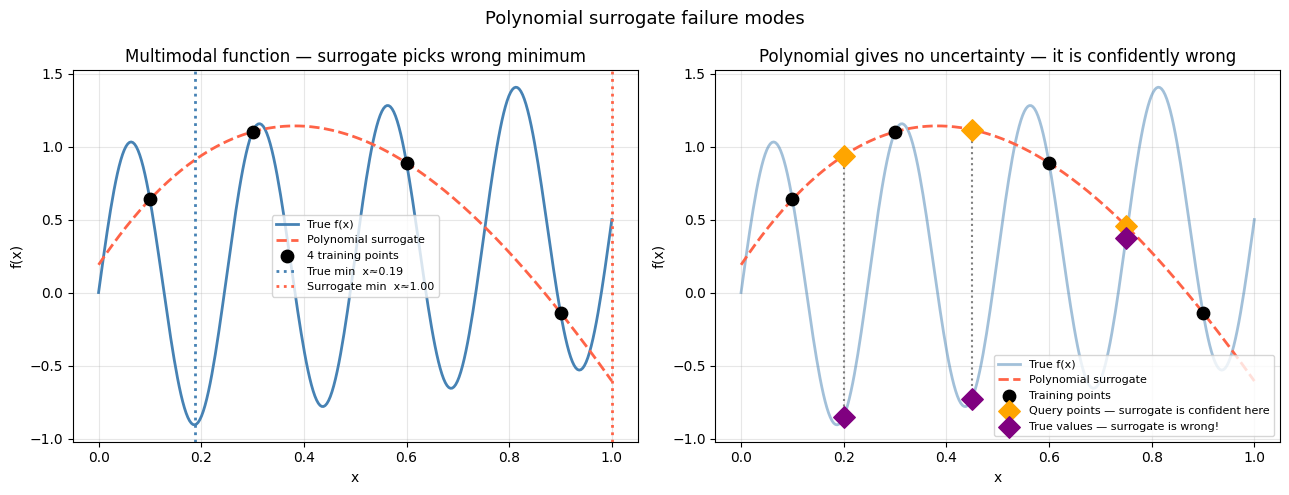

In [11]:
def multimodal(x):
    return np.sin(8 * np.pi * x) + 0.5 * x

X_sparse = np.array([0.1, 0.3, 0.6, 0.9])
y_sparse  = multimodal(X_sparse)
poly_fail = np.poly1d(np.polyfit(X_sparse, y_sparse, deg=3))

x_true_min = X_PLOT[np.argmin(multimodal(X_PLOT))]
x_surr_min = X_PLOT[np.argmin(poly_fail(X_PLOT))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(X_PLOT, multimodal(X_PLOT), color='steelblue', linewidth=2, label='True f(x)')
axes[0].plot(X_PLOT, poly_fail(X_PLOT), color='tomato', linewidth=2,
             linestyle='--', label='Polynomial surrogate')
axes[0].scatter(X_sparse, y_sparse, color='black', s=80, zorder=5, label='4 training points')
axes[0].axvline(x_true_min, color='steelblue', linestyle=':', linewidth=2,
                label=f'True min  x≈{x_true_min:.2f}')
axes[0].axvline(x_surr_min, color='tomato', linestyle=':', linewidth=2,
                label=f'Surrogate min  x≈{x_surr_min:.2f}')
axes[0].set_title('Multimodal function — surrogate picks wrong minimum')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Why: polynomial has no concept of uncertainty
x_query = np.array([0.2, 0.45, 0.75])  # points we have not seen
axes[1].plot(X_PLOT, multimodal(X_PLOT), color='steelblue', linewidth=2,
             label='True f(x)', alpha=0.5)
axes[1].plot(X_PLOT, poly_fail(X_PLOT), color='tomato', linewidth=2,
             linestyle='--', label='Polynomial surrogate')
axes[1].scatter(X_sparse, y_sparse, color='black', s=80, zorder=5, label='Training points')
axes[1].scatter(x_query, poly_fail(x_query), color='orange', s=120, zorder=6,
                marker='D', label='Query points — surrogate is confident here')
axes[1].scatter(x_query, multimodal(x_query), color='purple', s=120, zorder=6,
                marker='D', label='True values — surrogate is wrong!')
for xq in x_query:
    axes[1].plot([xq, xq], [poly_fail(xq), multimodal(xq)], color='gray',
                 linestyle=':', linewidth=1.5)
axes[1].set_title('Polynomial gives no uncertainty — it is confidently wrong')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Polynomial surrogate failure modes', fontsize=13)
plt.tight_layout()
plt.show()

The orange and purple diamonds show the gap between what the surrogate predicts and what the true function returns. The polynomial has no way to say "I am not sure here" — it just returns a number with full confidence, even when it is completely wrong.

**This is exactly what Gaussian Processes and Neural Networks with MC Dropout fix:**
- They return a **mean** (prediction) and a **variance** (uncertainty)
- High variance = the surrogate knows it doesn't know → explore that region
- Low variance = the surrogate is confident → trust the prediction

---
## Summary

| Concept | What it means |
|---|---|
| Surrogate | Cheap model trained on a few expensive evaluations |
| Surrogate loop | Fit → find min → evaluate → repeat |
| RMSE | Average error of the surrogate across the input space |
| Underfitting | Model too simple — misses the shape |
| Overfitting | Model too complex — memorises noise, oscillates |
| No uncertainty | Polynomial's fatal flaw — can't tell where it's wrong |

**The polynomial surrogate is a starting point, not a solution.**

Next we build up the math for a much better surrogate:
- **Lesson 4–5:** Statistics and kernels
- **Lesson 6:** Gaussian Process — uncertainty-aware surrogate
- **Lesson 9–10:** Neural Network with MC Dropout — our main contribution

---

## Exercises

1. Change polynomial degree to `15` in Part 3. What happens at the edges of the input space?
2. In Part 4, replace `x_next = X_PLOT[np.argmin(y_surr)]` with `x_next = rng.uniform(0, 1)` (random). How does convergence change compared to using the surrogate minimum?
3. Run the surrogate loop from Part 4 on `multimodal(x)` instead of `forrester(x)`. Does it find the global minimum?

---

## What's Next

**Lesson 4** — Statistics refresher. Gaussian distributions, covariance, and conditional distributions — the math that makes Gaussian Processes tick.